<a href="https://colab.research.google.com/github/eliasdengo/Python-practice-from-beginning-to-advance/blob/Eliasrepos/music_recommendation_system_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import that need for project

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
import string
import re

data processing

In [ ]:
# OR try this alternative approach
df = pd.read_csv('/content/sample_data/spotify_millsongdata.csv',
                 engine='python',        # Use Python engine which is more forgiving
                 on_bad_lines='skip')    # Skip problematic lines

In [ ]:
df.shape

(4232, 4)

In [ ]:
df.head()

,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nA..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gen..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,I'll never know why I had to go \r\nWhy I had...
3,ABBA,Bang,/a/abba/bang_20598415.html,Making somebody happy is a question of give an...
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,Making somebody happy is a question of give an...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10648 entries, 0 to 10647
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   artist  10648 non-null  object
 1   song    10648 non-null  object
 2   link    10648 non-null  object
 3   text    10648 non-null  object
dtypes: object(4)
memory usage: 332.9+ KB


In [ ]:
df.isnull().sum()

,0
artist,0
song,0
link,0
text,0


In [ ]:
# top artist
df['artist'].value_counts().head(10)

,count
artist,
Fleetwood Mac,156
James Taylor,132
Conway Twitty,121
ABBA,113
Air Supply,111
Chaka Khan,105
Eric Clapton,101
Barbra Streisand,94
Elvis Costello,93


In [ ]:
# word clould for song layrics
all_layerics= " ".join(df['text'].dropna())
wordclould=WordCloud(width=800,height=400,background_color='white').generate(all_layerics)

word cloud the most visualize to use

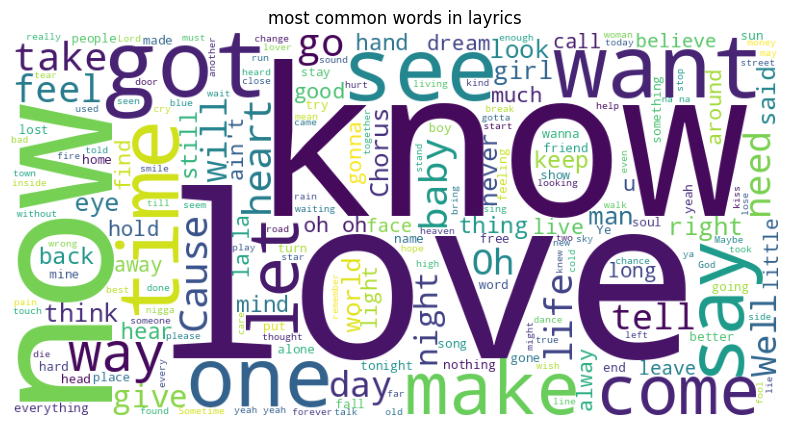

In [ ]:
# visualize word clould
plt.figure(figsize=(10,5))
plt.imshow(wordclould)
plt.axis('off')
plt.title('most common words in layrics')
plt.show()

Data Processing

In [ ]:
# download nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
stop_words=set(stopwords.words('english'))

NameError: name 'stopwords' is not defined

In [ ]:
def preprocess_text(text):
    # remove special carater and number
    text=re.sub(r'[^a-zA-Z]',' ',text)
    # conver to lower character
    text=text.lower()
    # tokenization
    tokens=word_tokenize(tex)
    tokens= [words from word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [ ]:
# apply preprocessed text in data
df['clear_text']=df['text'].apply(preprocess_text)

In [ ]:
# Recommendation song
def Recommendation_song(song_name,cosine_sim=cosine_sim,df=df,top_n=5):
  #find the index of song
  song_index=df[df['song']==song_name].index[0]
  if len(song_index)==0:
    return 'song not found'
  song_index=song_index[0]

  # get similarity scores
  sim_scores=list(enumerate(cosine_sim[song_index]))
  sim_scores=sorted(sim_scores,key=lambda x:x[1],reverse=True)
  sim_scores=sim_scores[1:top_n+1]
  song_indices=[i[0] for i in sim_scores]
  return df['artist','song'].iloc[song_indices]



In [ ]:
df['song'][2]

In [ ]:
# Example Recommendation
print('Recommendation for song')
recommendation=Recommendation_song('love story')
print(recommendation)